In [1]:
%cd /drive2/ryusejong/LFF
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "6,7"
import json 
import time 
import re
import random
import types
import math
import numpy as np 
from scipy.spatial.distance import cosine
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm.auto import tqdm
from util.utils import set_seed, read_data, save_result, get_answer_from_text, chat_huggingface, chat_huggingface_with_hidden_states, construct_conversation, normalize_answer, get_answer_response_from_text
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel

seed = 42
set_seed(seed)

def cosine_sim(a, b):
    return 1 - cosine(a, b)

/drive2/ryusejong/LFF


/drive2/ryusejong/miniconda3/envs/llm1/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
def step_score_hiddens(question, reasoning, model, tokenizer):
    print("-"*50)
    
    reasoning_steps = [l.strip() for l in reasoning.split("\n") if l.strip()]
    print(f"# steps: {len(reasoning_steps)}")

    model_input_text = question + ' \n\n' + ' \n\n\n\n'.join(reasoning_steps) + ' \n\n\n\n'

    ### original score
    with torch.no_grad():
        ### encode input text
        model_input = torch.tensor([tokenizer.encode(model_input_text)]).to(model.device)
        
        ### model output
        outputs = model(model_input, output_hidden_states=True, return_dict=True)
        
        ### get scores from step delimeter
        candidate_tokens = [12, 10]
        model_logits = outputs.logits[:,:,candidate_tokens]
        model_scores = model_logits.softmax(dim=-1)[:,:,1]
        step_scores = model_scores[model_input == 23535]
        step_probs  = step_scores.tolist()
        
        ### candidate token embedding
        embedding_matrix = model.get_input_embeddings().weight  # [vocab_size, hidden_dim]
        candidate_embeds = embedding_matrix[candidate_tokens].cpu().to(torch.float32).numpy()
        
        ### get hidden states from step delimeter 
        hidden_states = outputs.hidden_states   # list of tensors: [batch_size, seq_len, hidden_dim]
        final_hidden = hidden_states[-1][0]     # [seq_len, hidden_dim]
        step_hidden_states = final_hidden[model_input[0] == 23535]  # [num_steps, hidden_dim]
        step_hidden_states = step_hidden_states.cpu().to(torch.float32).numpy()
        
        ### get mean representation of the question
        q_len = len(tokenizer.encode(question))
        question_hidden_states = final_hidden[:q_len].cpu().to(torch.float32)
        question_mean_rep = question_hidden_states.mean(dim=0).numpy()  # [hidden_dim]
    
    print(f"Step scores: {step_scores}")
    print(f"Step hiddens shape: {step_hidden_states.shape}")
    print(f"Question mean hidden shape: {question_mean_rep.shape}")
    print(f"Candidate Embeddings shape: {candidate_embeds.shape}")
    print(f"Cosine between Candiate Embeds: {cosine(candidate_embeds[0], candidate_embeds[1])}")
    
    return reasoning_steps, step_probs, step_hidden_states, question_mean_rep, candidate_embeds

In [11]:
def step_hiddens(question, reasoning, model, tokenizer):
    print("-" * 50)

    reasoning_steps = [l.strip() for l in reasoning.split("\n") if l.strip()]
    print(f"# steps: {len(reasoning_steps)}")

    delim = ' \n\n'
    delim_token_len = len(tokenizer.encode(delim, add_special_tokens=False))
    delim_token_id = tokenizer.encode(delim, add_special_tokens=False)[0]  # assume 1 token

    step_hidden_states = []

    ### Step 1: Encode question only
    cumulative_text = question + delim
    model_input = torch.tensor([tokenizer.encode(cumulative_text)]).to(model.device)

    with torch.no_grad():
        outputs = model(model_input, output_hidden_states=True, return_dict=True)
        final_hidden = outputs.hidden_states[-1][0]  # [seq_len, hidden_dim]

        # Exclude final delimiter
        question_hidden = final_hidden[:-delim_token_len]
        question_mean_rep = question_hidden.mean(dim=0).cpu().to(torch.float32).numpy()

    ### Step 2: Step-by-step accumulation
    for step in reasoning_steps:
        cumulative_text += step + delim
        model_input = torch.tensor([tokenizer.encode(cumulative_text)]).to(model.device)

        with torch.no_grad():
            outputs = model(model_input, output_hidden_states=True, return_dict=True)
            final_hidden = outputs.hidden_states[-1][0]  # [seq_len, hidden_dim]

            # only current step's tokens
            step_tokens = tokenizer.encode(step, add_special_tokens=False)
            step_len = len(step_tokens)

            step_hidden = final_hidden[-(step_len + delim_token_len):-delim_token_len]
            step_embed = step_hidden.mean(dim=0).cpu().to(torch.float32).numpy()
            step_hidden_states.append(step_embed)

    step_hidden_states = np.stack(step_hidden_states)  # [num_steps, hidden_dim]

    print(f"Step hiddens shape: {step_hidden_states.shape}")
    print(f"Question mean hidden shape: {question_mean_rep.shape}")

    return reasoning_steps, step_hidden_states, question_mean_rep



In [12]:
def plot_tsne_2D(step_hiddens, question_mean_hidden, candidate_embeds=None):
    origin = np.zeros(step_hiddens.shape[1])
    if candidate_embeds is None:
        vecs = np.concatenate([origin[None, :], step_hiddens, question_mean_hidden[None, :]])
        labels = ['org'] + ['step' + str(i+1) for i in range(step_hiddens.shape[0])] + ['q_mean']
    else:
        vecs = np.concatenate([origin[None, :], step_hiddens, question_mean_hidden[None, :], candidate_embeds])
        labels = ['org'] + ['step' + str(i+1) for i in range(step_hiddens.shape[0])] + ['q_mean'] + ['corr.', 'incorr.']

    # t-SNE로 2차원 축소
    tsne = TSNE(n_components=2, perplexity=2, random_state=42, init='random')
    vecs_2d = tsne.fit_transform(vecs)

    # 시각화
    plt.figure(figsize=(6, 6))
    plt.scatter(vecs_2d[:, 0], vecs_2d[:, 1], s=100)

    for i, label in enumerate(labels):
        plt.text(vecs_2d[i, 0] + 0.01, vecs_2d[i, 1] + 0.01, label, fontsize=12)

    plt.title("t-SNE (2D) Visualization with Labels")
    plt.grid(True)
    plt.show()

In [13]:
def plot_tsne_3D(step_hiddens, question_mean_hidden, candidate_embeds=None):
    origin = np.zeros(step_hiddens.shape[1])
    if candidate_embeds is None:
        vecs = np.concatenate([origin[None, :], step_hiddens, question_mean_hidden[None, :]])
        labels = ['org'] + ['step' + str(i+1) for i in range(step_hiddens.shape[0])] + ['q_mean']
    else:
        vecs = np.concatenate([origin[None, :], step_hiddens, question_mean_hidden[None, :], candidate_embeds])
        labels = ['org'] + ['step' + str(i+1) for i in range(step_hiddens.shape[0])] + ['q_mean'] + ['corr.', 'incorr.']

    # t-SNE 3D 차원 축소
    tsne = TSNE(n_components=3, perplexity=2, random_state=42, init='random')
    vecs_3d = tsne.fit_transform(vecs)

    # 3D plot
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(vecs_3d[:, 0], vecs_3d[:, 1], vecs_3d[:, 2], s=100)

    for i, label in enumerate(labels):
        ax.text(vecs_3d[i, 0], vecs_3d[i, 1], vecs_3d[i, 2], label, size=12)

    ax.set_title("t-SNE (3D) Visualization with Labels")
    ax.set_xlabel("t-SNE1")
    ax.set_ylabel("t-SNE2")
    ax.set_zlabel("t-SNE3")
    plt.show()

## PRM

In [ ]:
### laod prm model
prm_path = "UW-Madison-Lee-Lab/Llama-PRM800K"
device1 = "cuda:0" if torch.cuda.is_available() else "cpu"

prm_tokenizer = AutoTokenizer.from_pretrained(prm_path)
prm_tokenizer.pad_token = prm_tokenizer.eos_token
prm_tokenizer.padding_side = 'left' 
prm_tokenizer.truncation_side = 'left'
    
prm = AutoModelForCausalLM.from_pretrained(
    prm_path,
    torch_dtype=torch.bfloat16,
    device_map=device1
)
prm.eval()

## Inference Model

In [ ]:
### inference model
HUGGINGFACE_TOKEN = "xxx"
model_path = "meta-llama/Meta-Llama-3-8B-Instruct"
device2 = "cuda:1" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_path, token=HUGGINGFACE_TOKEN)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
    
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    token=HUGGINGFACE_TOKEN,
    torch_dtype=torch.bfloat16,
    device_map=device2
)
model.generation_config.temperature=None
model.generation_config.top_p=None
model.eval()

--------------------------------------------------
# steps: 6
Step scores: tensor([0.9492, 0.6094, 0.9648, 0.9727, 0.9414, 0.9414], device='cuda:0',
       dtype=torch.bfloat16)
Step hiddens shape: (6, 4096)
Question mean hidden shape: (4096,)
Candidate Embeddings shape: (2, 4096)
Cosine between Candiate Embeds: 0.6869105696678162
--------------------------------------------------
# steps: 6
Step hiddens shape: (6, 4096)
Question mean hidden shape: (4096,)
--------------------------------------------------
Step 1: Let's break it down step-by-step!
PRM Prob: 0.9492
RPM Cosine with Question: 0.2105
Model Cosine with Question: 0.7297
PRM Cosine with Candidate Embeds: 0.0139, -0.0341
--------------------------------------------------
Step 2: 1. Bryan starts with 3 sets of 15 push-ups each. So, he does 3 x 15 = 45 push-ups in the first two sets.
PRM Prob: 0.6094
RPM Cosine with Question: 0.1024
Model Cosine with Question: 0.8067
PRM Cosine with Candidate Embeds: 0.0091, -0.0337
------------

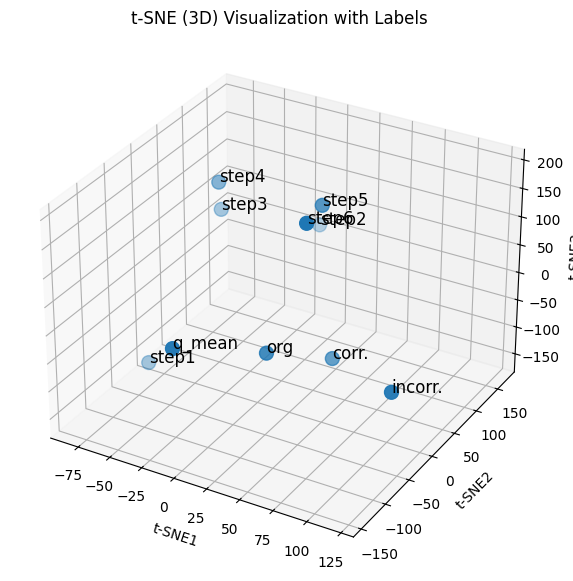

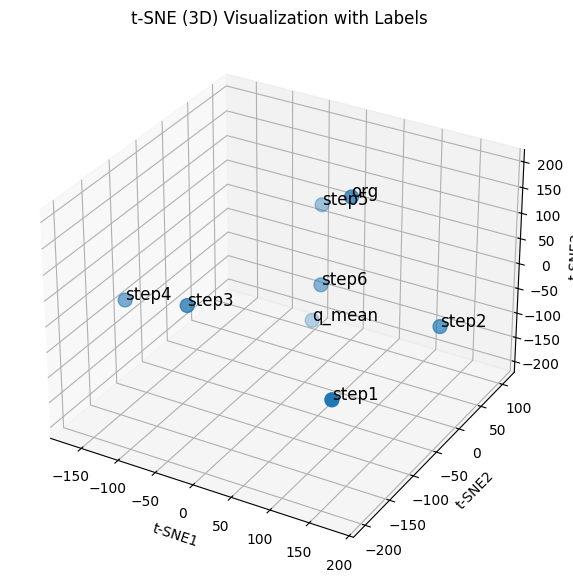

In [14]:
### incorrect case
question = "Bryan starts exercising at home during quarantine. To start, he decides to do 3 sets of 15 push-ups each. Near the end of the third set, he gets tired and does 5 fewer push-ups. How many push-ups did he do in total? Explain your reasoning step-by-step. Your final answer should be put between two ##, like ## 1 ## (if your final answer is 1), at the end of your response."

reasoning = "Let's break it down step-by-step!\n\n1. Bryan starts with 3 sets of 15 push-ups each. So, he does 3 x 15 = 45 push-ups in the first two sets.\n2. In the third set, he does 5 fewer push-ups than usual. So, he does 15 - 5 = 10 push-ups in the third set.\n3. To find the total number of push-ups, we add the number of push-ups in the first two sets (45) to the number of push-ups in the third set (10).\n\n45 + 10 = 55\n\n## 55 ##"

### prm
prm_steps, prm_step_probs, prm_step_hiddens, prm_question_mean_hidden, prm_candidate_embeds = step_score_hiddens(question, reasoning, prm, prm_tokenizer)

### inference model
model_steps, model_step_hiddens, model_question_mean_hidden = step_hiddens(question, reasoning, model, tokenizer)

for i, (step, prob) in enumerate(zip(prm_steps, prm_step_probs)):
    print("-"*50)
    print(f"Step {i+1}: {step}")
    print(f"PRM Prob: {prob:.4f}")
    print(f"RPM Cosine with Question: {cosine_sim(prm_step_hiddens[i], prm_question_mean_hidden):.4f}")
    print(f"Model Cosine with Question: {cosine_sim(model_step_hiddens[i], model_question_mean_hidden):.4f}")
    print(f"PRM Cosine with Candidate Embeds: {cosine_sim(prm_step_hiddens[i], prm_candidate_embeds[0]):.4f}, {cosine_sim(prm_step_hiddens[i], prm_candidate_embeds[1]):.4f}")
    #for j in range(i):
    #    print(f"Cosine with Step {j+1}: {cosine(prm_step_hiddens[i], prm_step_hiddens[j]):.4f}")

plot_tsne_3D(prm_step_hiddens, prm_question_mean_hidden, prm_candidate_embeds)
plot_tsne_3D(model_step_hiddens, model_question_mean_hidden)
    

--------------------------------------------------
# steps: 7
Step scores: tensor([0.9219, 0.8789, 0.9102, 0.7930, 0.6523, 0.9336, 0.8945],
       device='cuda:0', dtype=torch.bfloat16)
Step hiddens shape: (7, 4096)
Question mean hidden shape: (4096,)
Candidate Embeddings shape: (2, 4096)
Cosine between Candiate Embeds: 0.6869105696678162
--------------------------------------------------
# steps: 7
Step hiddens shape: (7, 4096)
Question mean hidden shape: (4096,)
--------------------------------------------------
Step 1: Let's break this down step by step!
PRM Prob: 0.9219
RPM Cosine with Question: 0.1578
Model Cosine with Question: 0.6957
PRM Cosine with Candidate Embeds: 0.0168, -0.0334
--------------------------------------------------
Step 2: 1. There are 40 guests arriving in 10 cars. This means that each car has 40/10 = 4 guests.
PRM Prob: 0.8789
RPM Cosine with Question: 0.1406
Model Cosine with Question: 0.7922
PRM Cosine with Candidate Embeds: 0.0148, -0.0336
----------------

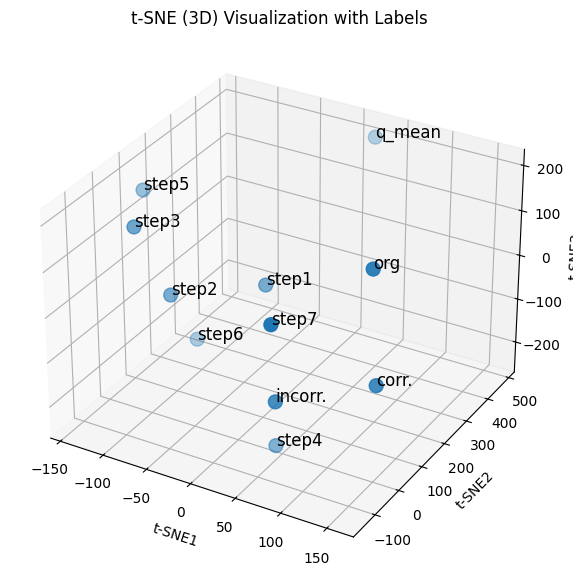

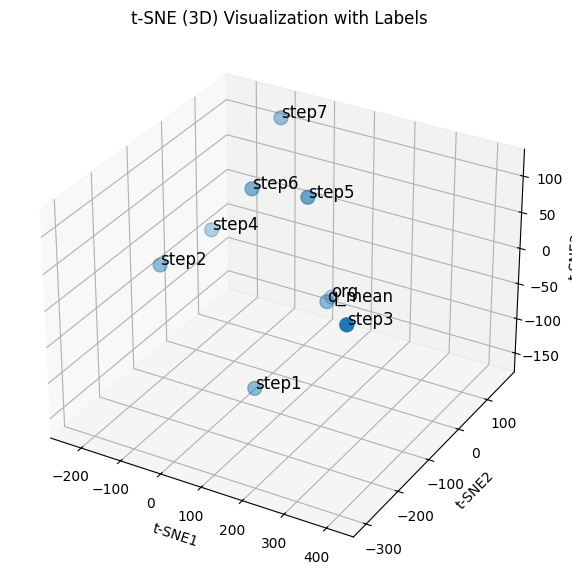

In [15]:
### incorrect case
question = "Dylan's mother is throwing a baby shower for her best friend. She is expecting 40 guests, of whom she has cleared the parking lot to park in to, leaving only her car and her husband's jeep in the parking lot. The 40 guests, though, arrive in only 10 cars that they park in the parking lot.  If each car has 4 wheels, how many car wheels are there in the parking lot, including both of Dylan's parent's car wheels? Explain your reasoning step-by-step. Your final answer should be put between two ##, like ## 1 ## (if your final answer is 1), at the end of your response."

reasoning = "Let's break this down step by step!\n\n1. There are 40 guests arriving in 10 cars. This means that each car has 40/10 = 4 guests.\n2. Each car has 4 wheels, so each car has a total of 4 x 4 = 16 wheels.\n3. There are 10 cars in total, so the total number of wheels is 10 x 16 = 160 wheels.\n4. Dylan's mother and father have 2 cars in the parking lot, which are their own car and their husband's jeep. Each of these cars has 4 wheels, so the total number of wheels for these 2 cars is 2 x 4 = 8 wheels.\n5. Adding the wheels from the 10 guest cars (160) to the wheels from Dylan's parents' cars (8), we get a total of 160 + 8 = 168 wheels in the parking lot.\n\n## 168 ##"

### prm
prm_steps, prm_step_probs, prm_step_hiddens, prm_question_mean_hidden, prm_candidate_embeds = step_score_hiddens(question, reasoning, prm, prm_tokenizer)

### inference model
model_steps, model_step_hiddens, model_question_mean_hidden = step_hiddens(question, reasoning, model, tokenizer)

for i, (step, prob) in enumerate(zip(prm_steps, prm_step_probs)):
    print("-"*50)
    print(f"Step {i+1}: {step}")
    print(f"PRM Prob: {prob:.4f}")
    print(f"RPM Cosine with Question: {cosine_sim(prm_step_hiddens[i], prm_question_mean_hidden):.4f}")
    print(f"Model Cosine with Question: {cosine_sim(model_step_hiddens[i], model_question_mean_hidden):.4f}")
    print(f"PRM Cosine with Candidate Embeds: {cosine_sim(prm_step_hiddens[i], prm_candidate_embeds[0]):.4f}, {cosine_sim(prm_step_hiddens[i], prm_candidate_embeds[1]):.4f}")
    #for j in range(i):
    #    print(f"Cosine with Step {j+1}: {cosine(prm_step_hiddens[i], prm_step_hiddens[j]):.4f}")

plot_tsne_3D(prm_step_hiddens, prm_question_mean_hidden, prm_candidate_embeds)
plot_tsne_3D(model_step_hiddens, model_question_mean_hidden)

--------------------------------------------------
# steps: 8
Step scores: tensor([0.9570, 0.9258, 0.9922, 0.9961, 0.9883, 0.9922, 0.9922, 0.9609],
       device='cuda:0', dtype=torch.bfloat16)
Step hiddens shape: (8, 4096)
Question mean hidden shape: (4096,)
Candidate Embeddings shape: (2, 4096)
Cosine between Candiate Embeds: 0.6869105696678162
--------------------------------------------------
Step 1: Let's break this problem down step by step!
Prob: 0.9570
Cosine with Question: 0.2649
Cosine with Candidate Embeds: 0.0153, -0.0307
Softmax Scores with Candidate Embeds: [0.93342185 0.06657818]
--------------------------------------------------
Step 2: 1. Jane picked 64 apples and sorted them into 4 baskets. To find out how many apples are in each basket initially, we can divide the total number of apples (64) by the number of baskets (4):
Prob: 0.9258
Cosine with Question: 0.2185
Cosine with Candidate Embeds: 0.0085, -0.0306
Softmax Scores with Candidate Embeds: [0.9106141  0.08938595

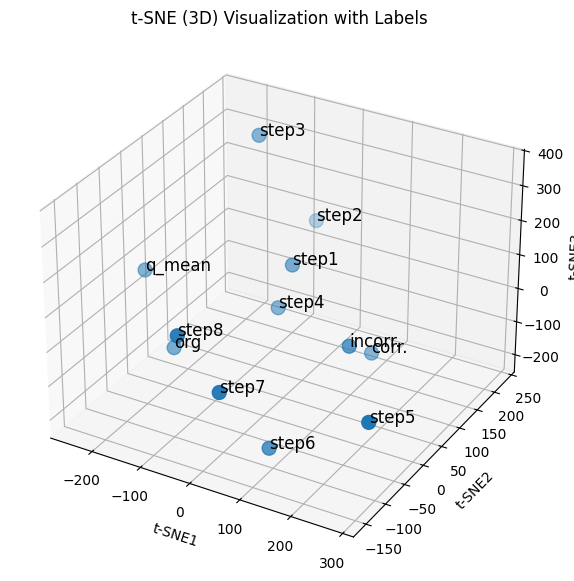

In [10]:
### correct case
question = "Jane picked 64 apples at the orchard. She sorted them into 4 different baskets to send to her friends. When Jane wasn't looking her sister took 3 apples from each of the baskets. How many apples are in each basket now? Explain your reasoning step-by-step. Your final answer should be put between two ##, like ## 1 ## (if your final answer is 1), at the end of your response."

reasoning = "Let's break this problem down step by step!\n\n1. Jane picked 64 apples and sorted them into 4 baskets. To find out how many apples are in each basket initially, we can divide the total number of apples (64) by the number of baskets (4):\n\n64 \u00f7 4 = 16\n\nSo, each basket initially had 16 apples.\n\n2. Jane's sister took 3 apples from each of the baskets. To find out how many apples are left in each basket, we need to subtract 3 from the initial number of apples in each basket (16):\n\n16 - 3 = 13\n\nSo, each basket now has 13 apples.\n\n## 13 ##"

### basic
steps, step_probs, step_hiddens, question_mean_hidden, candidate_embeds = step_score_hiddens(question, reasoning, prm, prm_tokenizer)

for i, (step, prob) in enumerate(zip(steps, step_probs)):
    print("-"*50)
    print(f"Step {i+1}: {step}")
    print(f"Prob: {prob:.4f}")
    print(f"Cosine with Question: {cosine_sim(step_hiddens[i], question_mean_hidden):.4f}")
    print(f"Cosine with Candidate Embeds: {cosine_sim(step_hiddens[i], candidate_embeds[0]):.4f}, {cosine_sim(step_hiddens[i], candidate_embeds[1]):.4f}")
    #print(f"Products with Candidate Embeds: {np.dot(step_hiddens[i], candidate_embeds.T)}")
    print(f"Softmax Scores with Candidate Embeds: {np.exp(np.dot(step_hiddens[i], candidate_embeds.T)) / np.sum(np.exp(np.dot(step_hiddens[i], candidate_embeds.T)))}")
    #for j in range(i):
    #    print(f"Cosine with Step {j+1}: {cosine(step_hiddens[i], step_hiddens[j]):.4f}")

plot_tsne_3D(step_hiddens, question_mean_hidden, candidate_embeds)

--------------------------------------------------
# steps: 7
Step scores: tensor([0.9609, 0.9375, 0.9961, 0.9297, 0.9688, 0.9766, 0.9297],
       device='cuda:0', dtype=torch.bfloat16)
Step hiddens shape: (7, 4096)
Question mean hidden shape: (4096,)
Candidate Embeddings shape: (2, 4096)
Cosine between Candiate Embeds: 0.6869105696678162
--------------------------------------------------
Step 1: Let's break this down step by step.
Prob: 0.9609
Cosine with Question: 0.2651
Cosine with Candidate Embeds: 0.0143, -0.0278
Softmax Scores with Candidate Embeds: [0.91729695 0.08270305]
--------------------------------------------------
Step 2: 1. Tim rides his bike to and from work for 5 days. This means he rides a total of 20 miles * 2 (there and back) * 5 days = 200 miles.
Prob: 0.9375
Cosine with Question: 0.2163
Cosine with Candidate Embeds: 0.0081, -0.0290
Softmax Scores with Candidate Embeds: [0.899751   0.10024898]
--------------------------------------------------
Step 3: 2. He also g

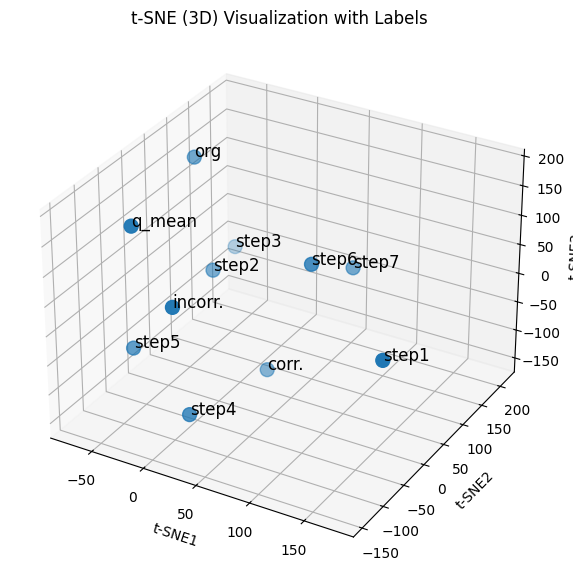

In [11]:
### correct case
question = "Tim rides his bike back and forth to work for each of his 5 workdays.  His work is 20 miles away.  He also goes for a weekend bike ride of 200 miles.    If he can bike at 25 mph how much time does he spend biking a week? Explain your reasoning step-by-step. Your final answer should be put between two ##, like ## 1 ## (if your final answer is 1), at the end of your response."

reasoning = "Let's break this down step by step.\n\n1. Tim rides his bike to and from work for 5 days. This means he rides a total of 20 miles * 2 (there and back) * 5 days = 200 miles.\n2. He also goes for a weekend bike ride of 200 miles.\n3. To find the total distance Tim bikes in a week, we add the distance he bikes to and from work (200 miles) to the distance he bikes on the weekend (200 miles). This gives us a total distance of 200 + 200 = 400 miles.\n4. Tim bikes at a speed of 25 mph. To find the time it takes him to bike a certain distance, we can use the formula: time = distance / speed.\n5. Plugging in the values, we get: time = 400 miles / 25 mph = 16 hours.\n\n## 16 ##"

### basic
steps, step_probs, step_hiddens, question_mean_hidden, candidate_embeds = step_score_hiddens(question, reasoning, prm, prm_tokenizer)

for i, (step, prob) in enumerate(zip(steps, step_probs)):
    print("-"*50)
    print(f"Step {i+1}: {step}")
    print(f"Prob: {prob:.4f}")
    print(f"Cosine with Question: {cosine_sim(step_hiddens[i], question_mean_hidden):.4f}")
    print(f"Cosine with Candidate Embeds: {cosine_sim(step_hiddens[i], candidate_embeds[0]):.4f}, {cosine_sim(step_hiddens[i], candidate_embeds[1]):.4f}")
    #print(f"Products with Candidate Embeds: {np.dot(step_hiddens[i], candidate_embeds.T)}")
    print(f"Softmax Scores with Candidate Embeds: {np.exp(np.dot(step_hiddens[i], candidate_embeds.T)) / np.sum(np.exp(np.dot(step_hiddens[i], candidate_embeds.T)))}")
    #for j in range(i):
    #    print(f"Cosine with Step {j+1}: {cosine(step_hiddens[i], step_hiddens[j]):.4f}")

plot_tsne_3D(step_hiddens, question_mean_hidden, candidate_embeds)

--------------------------------------------------
# steps: 9
Step scores: tensor([0.9531, 0.6016, 0.9688, 0.9961, 0.9922, 0.9023, 0.9766, 0.9844, 0.9102],
       device='cuda:0', dtype=torch.bfloat16)
Step hiddens shape: (9, 4096)
Question mean hidden shape: (4096,)
Candidate Embeddings shape: (2, 4096)
Cosine between Candiate Embeds: 0.6869105696678162
--------------------------------------------------
Step 1: Let's break it down step by step!
Prob: 0.9531
Cosine with Question: 0.2146
Cosine with Candidate Embeds: 0.0144, -0.0309
Softmax Scores with Candidate Embeds: [0.9307078  0.06929216]
--------------------------------------------------
Step 2: Last month, Noah sold:
Prob: 0.6016
Cosine with Question: 0.2970
Cosine with Candidate Embeds: 0.0106, -0.0234
Softmax Scores with Candidate Embeds: [0.8811712 0.1188288]
--------------------------------------------------
Step 3: * 8 large paintings at $60 each = 8 x $60 = $480
Prob: 0.9688
Cosine with Question: 0.1807
Cosine with Candidat

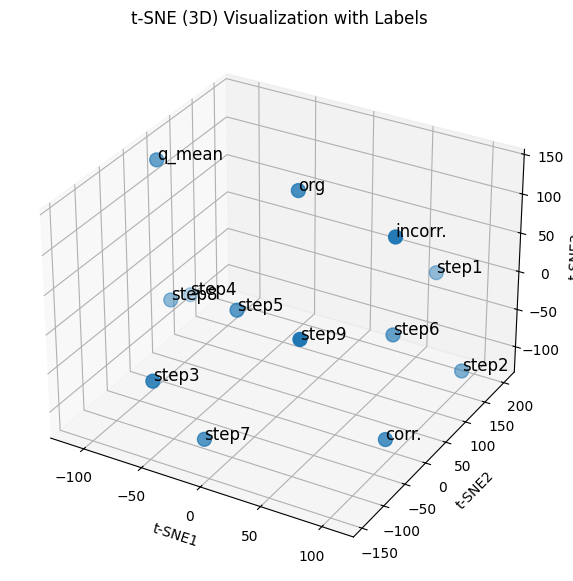

In [12]:
### correct case
question = "Noah is a painter. He paints pictures and sells them at the park. He charges $60 for a large painting and $30 for a small painting. Last month he sold eight large paintings and four small paintings. If he sold twice as much this month, how much is his sales for this month? Explain your reasoning step-by-step. Your final answer should be put between two ##, like ## 1 ## (if your final answer is 1), at the end of your response."
reasoning = "Let's break it down step by step!\n\nLast month, Noah sold:\n\n* 8 large paintings at $60 each = 8 x $60 = $480\n* 4 small paintings at $30 each = 4 x $30 = $120\n\nTotal sales last month = $480 + $120 = $600\n\nThis month, Noah sold twice as much as last month. So, he sold:\n\n* 2 x 8 = 16 large paintings at $60 each = 16 x $60 = $960\n* 2 x 4 = 8 small paintings at $30 each = 8 x $30 = $240\n\nTotal sales this month = $960 + $240 = ## $1,200 ##"

### basic
steps, step_probs, step_hiddens, question_mean_hidden, candidate_embeds = step_score_hiddens(question, reasoning, prm, prm_tokenizer)

for i, (step, prob) in enumerate(zip(steps, step_probs)):
    print("-"*50)
    print(f"Step {i+1}: {step}")
    print(f"Prob: {prob:.4f}")
    print(f"Cosine with Question: {cosine_sim(step_hiddens[i], question_mean_hidden):.4f}")
    print(f"Cosine with Candidate Embeds: {cosine_sim(step_hiddens[i], candidate_embeds[0]):.4f}, {cosine_sim(step_hiddens[i], candidate_embeds[1]):.4f}")
    #print(f"Products with Candidate Embeds: {np.dot(step_hiddens[i], candidate_embeds.T)}")
    print(f"Softmax Scores with Candidate Embeds: {np.exp(np.dot(step_hiddens[i], candidate_embeds.T)) / np.sum(np.exp(np.dot(step_hiddens[i], candidate_embeds.T)))}")
    #for j in range(i):
    #    print(f"Cosine with Step {j+1}: {cosine(step_hiddens[i], step_hiddens[j]):.4f}")

plot_tsne_3D(step_hiddens, question_mean_hidden, candidate_embeds)